## Synthetic Difference-in-Difference (SDID)

╭──────────────────────────────────────────────────────────────────────────────╮
|                               CaliforniaProp99                               |
├──────────────────────────────────────────────────────────────────────────────┤
|                                    Panel                                     |
|  Time Periods: 31 (19/12)                                  total (pre/post)  |
|  Units: 39 (38/1)                                       total (contr/treat)  |
├──────────────────────────────────────────────────────────────────────────────┤
|                                     ATT                                      |
|  Effect (±SE): -15.60 (±2.9161)                                              |
|  Confidence Interval (95%): [-21.32 , -9.8884]                          (-)  |
|  Observed: 60.35                                                             |
|  Counter Factual: 75.95                                                      |
├───────────────────────────

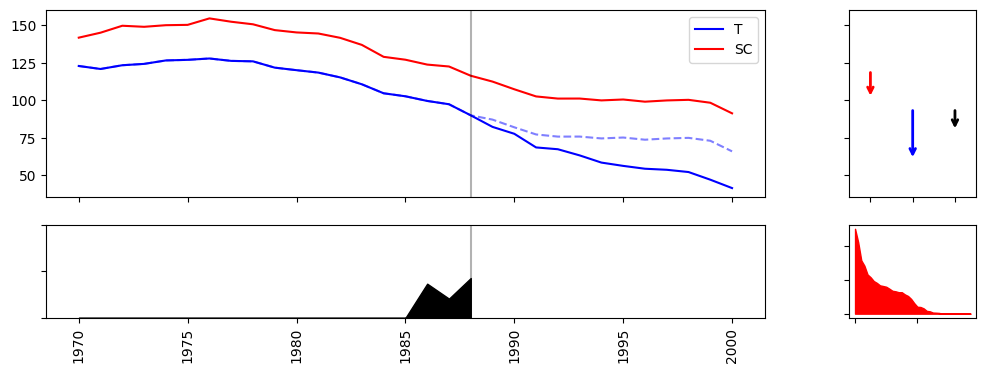

In [1]:
from azcausal.data import CaliforniaProp99
from azcausal.core.error import JackKnife
from azcausal.estimators.panel.sdid import SDID


# load an example data set with the columns Year, State, PacksPerCapita, treated.
panel = CaliforniaProp99().panel()

# initialize an estimator object, here synthetic difference in difference (sdid)
estimator = SDID()

# run the estimator
result = estimator.fit(panel)

# show the results in a plot
estimator.plot(result, CF=True, C=True, show=False)

# run an error validation method
estimator.error(result, JackKnife())

# print out information about the estimate
print(result.summary(title="CaliforniaProp99"))

In [2]:
# the weights of control units to create synthetic control
result.effect['omega'].sort_values(ascending=False).head(10)

Nevada           0.124489
New Hampshire    0.105048
Connecticut      0.078287
Delaware         0.070368
Colorado         0.057513
Illinois         0.053388
Nebraska         0.047853
Montana          0.045135
Utah             0.041518
New Mexico       0.040568
Name: omega, dtype: float64

In [3]:
# the weights of each time-step for weighted DID
result.effect['lambd'].sort_values(ascending=False).head(5)

1988    0.427076
1986    0.366471
1987    0.206453
1980    0.000000
1985    0.000000
Name: lambd, dtype: float64